## **Baseline A: Clinical Features Classification**

## 1. Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## 2. Load Clinical Dataset

In [20]:
df = pd.read_csv("aligned_clinical_dataset.csv")

print(df.shape)
df.head()

(1360, 9)


,ID,target,LeftRight,Age,Age_missing,Breast_density_encoded,BI_RADS,Mass_present,Calc_present
0,D1-0001,0,R,44.0,0.0,2.0,2.0,0.0,1.0
1,D1-0002,0,L,40.0,0.0,2.0,2.0,0.0,1.0
2,D1-0003,0,L,39.0,0.0,1.0,3.0,0.0,1.0
3,D1-0004,0,L,41.0,0.0,2.0,2.0,0.0,1.0
4,D1-0005,0,R,42.0,0.0,3.0,2.0,0.0,1.0


## 3. Define Features and Target

In [21]:
X = df.drop(columns=["ID", "LeftRight", "target"])
y = df["target"]

## 4. Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 5. Feature Scaling

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Handling Class Imbalance using SMOTE

In [27]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

## 6. Model 1: Logistic Regression

In [28]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8774509803921569
              precision    recall  f1-score   support

           0       0.55      0.88      0.68        59
           1       0.98      0.88      0.92       349

    accuracy                           0.88       408
   macro avg       0.76      0.88      0.80       408
weighted avg       0.92      0.88      0.89       408



## 7. Model 2: Random Forest

In [29]:
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8897058823529411
              precision    recall  f1-score   support

           0       0.62      0.63      0.62        59
           1       0.94      0.93      0.94       349

    accuracy                           0.89       408
   macro avg       0.78      0.78      0.78       408
weighted avg       0.89      0.89      0.89       408



## 8. Model 3: Support Vector Machine

In [31]:
svm = SVC(class_weight="balanced")
svm.fit(X_train_resampled, y_train_resampled)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8725490196078431
              precision    recall  f1-score   support

           0       0.54      0.86      0.66        59
           1       0.97      0.87      0.92       349

    accuracy                           0.87       408
   macro avg       0.76      0.87      0.79       408
weighted avg       0.91      0.87      0.88       408



## 9. Confusion Matrix for BEST model (Random Forest)

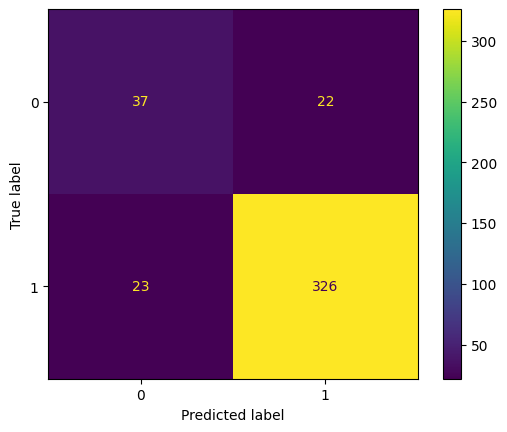

In [32]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

## 10. Feature Importance

In [33]:
feature_names = X.columns
coefficients = lr.coef_[0]

for name, coef in sorted(zip(feature_names, coefficients), key=lambda x: abs(x[1]), reverse=True):
    print(name, coef)

Age_missing 3.94763622287846
BI_RADS 2.0084589540904463
Age 0.6497281258224332
Calc_present 0.4888753333893091
Breast_density_encoded 0.29810800128242576
Mass_present 0.0001121117897357137


## 11. Model Comparison Visualization

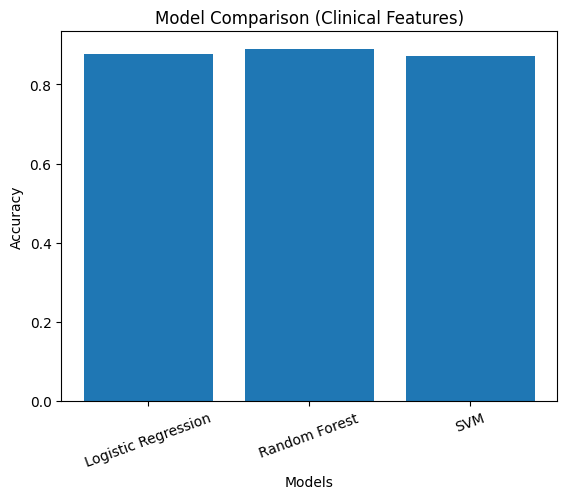

In [34]:
models = ["Logistic Regression", "Random Forest", "SVM"]
accuracies = [0.877, 0.889, 0.872]

plt.figure()
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Clinical Features)")

plt.xticks(rotation=20)
plt.show()

## 13. Feature Importance Plot

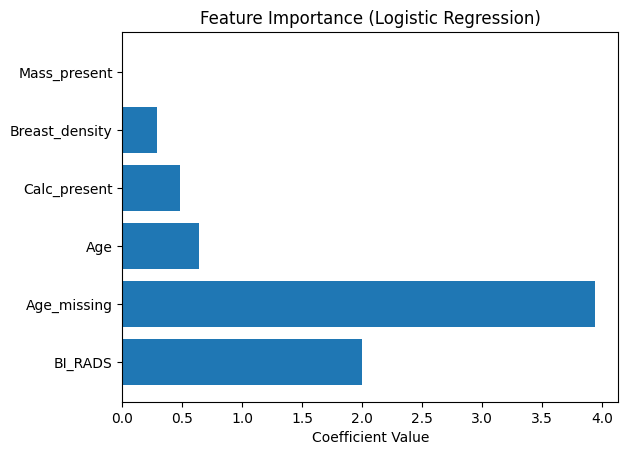

In [35]:
plt.figure()

features = ["BI_RADS", "Age_missing", "Age", "Calc_present", "Breast_density", "Mass_present"]
importance = [2.00, 3.94, 0.64, 0.48, 0.29, 0.00011]

plt.barh(features, importance)

plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Logistic Regression)")

plt.show()

## 14. Saving Results

In [ ]:
results = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

results.to_csv("baseline_A_model_comparison.csv", index=False)